In [43]:
# --- loads our saved trained models and the data ---

%run ./r_model_data_loader.ipynb

Test shape: (685159, 191)
Weeks: 44 - 91 (48 unieke weken)
Default rate: 0.0335 (22955 positieven)
LR : C=0.000195172, l1_ratio=0.0, n_features=191
XGB: n_trees=450, n_features=191
MLP: hidden=[128], n_features=191
Device: cpu


c:\Users\Vik\Documents\UGent\Masterproef\venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.9.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


# Results - Explainable Stability

## 3.3.0 Setup

De drie bevroren modellen worden uitgelegd met `shap.PermutationExplainer` op de log-odds
schaal, zodat de SHAP-waarden van LR, XGB en MLP in dezelfde eenheid staan. Dat gebeurt op
de raw featureruimte: de preprocessing (winsorisatie, imputatie, frequency encoding,
z-scoring) zit niet in een pipeline maar is in m2 al in de parquet verwerkt, dus de drie
modellen delen exact dezelfde kolommen en zijn de featurenamen zonder meer vergelijkbaar.

In [44]:
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import shap
from scipy import stats
from sklearn.linear_model import LogisticRegression

# --- SHAP config ---

TOP_K = 20
N_BACKGROUND = 50
N_BASELINE = 50
N_PER_WEEK = 50
SEED = 42
TRAIN_WEEKS = range(0, 44)
TEST_WEEKS = range(44, 92)
COVID_WEEK = 62
MAX_EVALS = 383  # 2 * 191 features + 1

RESULTS_DIR = "shap_results"
FIGURES_DIR = "figures"
CACHE_PATH = f"{RESULTS_DIR}/shap_cache.parquet"

BASELINE_WEEK = -1
MODELS = ["LR", "XGB", "MLP"]
COLORS = {"LR": "dimgray", "XGB": "crimson", "MLP": "darkorange"}

BLOCKS = {
    "volledig": [w for w in TEST_WEEKS],
    "pre-COVID": [w for w in TEST_WEEKS if w < COVID_WEEK],
    "post-COVID": [w for w in TEST_WEEKS if w >= COVID_WEEK],
}

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

models = {"LR": lr_best, "XGB": xgb_best, "MLP": mlp_best}

n_features = X_test.shape[1]
if MAX_EVALS < 2 * n_features + 1:
    raise ValueError(f"MAX_EVALS={MAX_EVALS} ligt onder het minimum van "
                     f"2 * {n_features} + 1 = {2 * n_features + 1}")

print(f"Features: {n_features}")
print(f"MAX_EVALS: {MAX_EVALS} (minimum 2 * {n_features} + 1 = {2 * n_features + 1})")

Features: 191
MAX_EVALS: 383 (minimum 2 * 191 + 1 = 383)


### Achtergrond- en baselinerijen

Eén trekking uit het volledige trainingsblok, daarna gesplitst in een achtergrondset (waartegen
gemaskeerd wordt) en een baselineset (de rijen die uitgelegd worden). Beide zijn identiek voor
de drie modellen; de baseline krijgt week = -1 in de cache.

In [45]:
train_df = pd.read_parquet(f"{DATA_DIR}/df_train_preprocessed_cutoff44.parquet")
train_df = train_df[train_df["WEEK_NUM"].isin(TRAIN_WEEKS)]

rng = np.random.default_rng(SEED)
draw = rng.choice(len(train_df), N_BACKGROUND + N_BASELINE, replace=False)
train_sample = train_df.iloc[np.sort(draw)].drop(columns=id_cols + ["target"])

background = train_sample.iloc[:N_BACKGROUND]
X_baseline = train_sample.iloc[N_BACKGROUND:]

del train_df

# max_samples moet expliciet: zonder dat argument dunt shap de background stil uit tot 100.
masker = shap.maskers.Independent(background, max_samples=N_BACKGROUND)

print(f"Background: {len(background)} rijen, baseline: {len(X_baseline)} rijen")
print(f"Zelfde kolommen als X_test: {list(background.columns) == list(X_test.columns)}")

Background: 50 rijen, baseline: 50 rijen
Zelfde kolommen als X_test: True


In [46]:
# De weektrekkingen worden vooraf gemaakt, zodat de drie modellen gegarandeerd op dezelfde
# rijen worden uitgelegd. week_num_test staat in dezelfde rijvolgorde als X_test (zie loader).
week_num = week_num_test.to_numpy()

week_samples = {}
for week in TEST_WEEKS:
    week_rows = np.flatnonzero(week_num == week)
    week_rng = np.random.default_rng([SEED, week])
    week_draw = week_rng.choice(week_rows, min(N_PER_WEEK, len(week_rows)), replace=False)
    week_samples[week] = X_test.iloc[np.sort(week_draw)]

print(f"Testweken: {min(week_samples)}-{max(week_samples)} ({len(week_samples)} weken), "
      f"{N_PER_WEEK} rijen per week")

Testweken: 44-91 (48 weken), 50 rijen per week


In [47]:
def predict_logodds(model, X):
    """Score op de log-odds schaal, zodat de SHAP-waarden van de drie modellen in
    dezelfde eenheid staan."""
    if isinstance(model, LogisticRegression):
        return model.decision_function(X)

    if isinstance(model, XGBClassifier):
        return model.predict(np.asarray(X, dtype=np.float32), output_margin=True)

    # De MLP is een TorchScript-module met één output, getraind met BCEWithLogitsLoss:
    # die output IS de logit. Sigmoid nemen en daar weer de logit van berekenen zou exact
    # dezelfde waarde opnieuw opbouwen en enkel precisie kosten. Het clippen houden we wel
    # aan, zodat de schaal eindig blijft.
    with torch.no_grad():
        logits = model(torch.tensor(np.asarray(X, dtype=np.float32), device=device))
    return np.clip(logits.cpu().numpy().ravel(), -30.0, 30.0)

In [48]:
def load_done_pairs():
    if not os.path.exists(CACHE_PATH):
        return set()
    cache = pd.read_parquet(CACHE_PATH, columns=["model", "week"])
    return set(zip(cache["model"], cache["week"]))


def append_to_cache(rows):
    if os.path.exists(CACHE_PATH):
        rows = pd.concat([pd.read_parquet(CACHE_PATH), rows], ignore_index=True)

    # Eerst volledig naar een tijdelijk bestand schrijven en dan pas vervangen: een crash
    # tijdens het schrijven laat de bestaande cache dan onbeschadigd achter.
    tmp_path = CACHE_PATH + ".tmp"
    rows.to_parquet(tmp_path, index=False)
    os.replace(tmp_path, CACHE_PATH)

### SHAP berekenen

Deze cel duurt ongeveer 6,5 uur (~0,3 s per uitgelegde rij per model, 500 rijen per week,
49 blokken per model). De cache wordt na elk (model, week) paar weggeschreven en al
berekende paren worden overgeslagen, dus de cel mag onderbroken en later hervat worden.

In [49]:
done = load_done_pairs()
if done:
    print(f"Cache bevat al {len(done)} (model, week) paren")

for model_name, model in models.items():

    def model_fn(X, model=model):
        return predict_logodds(model, X)

    explainer = shap.PermutationExplainer(model_fn, masker, seed=SEED)

    jobs = [(BASELINE_WEEK, X_baseline)]
    for week in TEST_WEEKS:
        jobs.append((week, week_samples[week]))

    for week, X_week in jobs:
        if (model_name, week) in done:
            print(f"{model_name:>3}  week {week:>3}  overgeslagen (al in cache)")
            continue

        start = time.perf_counter()

        # batch_size expliciet: de standaard "auto" kiest hier veel te kleine batches en
        # maakt de run ongeveer een factor drie trager.
        explanation = explainer(X_week, max_evals=MAX_EVALS, batch_size=50_000, silent=True)
        mean_abs_shap = np.abs(explanation.values).mean(axis=0)

        rows = pd.DataFrame({
            "model": model_name,
            "week": week,
            "feature": list(X_week.columns),
            "mean_abs_shap": mean_abs_shap,
        })
        append_to_cache(rows)

        print(f"{model_name:>3}  week {week:>3}  {time.perf_counter() - start:.1f}s")

print(f"Klaar. Cache: {CACHE_PATH}")

Cache bevat al 147 (model, week) paren
 LR  week  -1  overgeslagen (al in cache)
 LR  week  44  overgeslagen (al in cache)
 LR  week  45  overgeslagen (al in cache)
 LR  week  46  overgeslagen (al in cache)
 LR  week  47  overgeslagen (al in cache)
 LR  week  48  overgeslagen (al in cache)
 LR  week  49  overgeslagen (al in cache)
 LR  week  50  overgeslagen (al in cache)
 LR  week  51  overgeslagen (al in cache)
 LR  week  52  overgeslagen (al in cache)
 LR  week  53  overgeslagen (al in cache)
 LR  week  54  overgeslagen (al in cache)
 LR  week  55  overgeslagen (al in cache)
 LR  week  56  overgeslagen (al in cache)
 LR  week  57  overgeslagen (al in cache)
 LR  week  58  overgeslagen (al in cache)
 LR  week  59  overgeslagen (al in cache)
 LR  week  60  overgeslagen (al in cache)
 LR  week  61  overgeslagen (al in cache)
 LR  week  62  overgeslagen (al in cache)
 LR  week  63  overgeslagen (al in cache)
 LR  week  64  overgeslagen (al in cache)
 LR  week  65  overgeslagen (al in ca

## 3.3.1 Verklarende stabiliteit

Per model wordt de baselineband bevroren: de top-25 features van de baselinerijen (week = -1),
gesorteerd op mean |SHAP|. Die band verschilt per model, en dat is de bedoeling - elk model
wordt tegen zijn eigen uitgangspunt gelegd.

Vier metrieken op die band:

- **Spearman** - de TOP_K baselinefeatures onderling gerangschikt in de baseline tegenover
  diezelfde features onderling gerangschikt in week t. Meet enkel de volgorde.
- **Pearson** - dezelfde vergelijking maar op de mean |SHAP| zelf in plaats van op de rangen,
  dus ook gevoelig voor de grootte van de bijdragen. Blijft de volgorde gelijk terwijl één
  feature veel zwaarder gaat wegen, dan zakt Pearson terwijl Spearman hoog blijft.
- **Overlap** - de eigen top-25 van week t over ALLE features, doorsneden met de baselineband,
  gedeeld door TOP_K.
- **CoV** - per feature in de band de std (ddof=1) gedeeld door het gemiddelde over de weken
  van een blok, daarna gemiddeld over de TOP_K features. Eén waarde per blok.

In [50]:
cache = pd.read_parquet(CACHE_PATH)

weekly_rows = []
summary_rows = []
cov_per_feature = {}
bands = {}
tables = {}

for model_name in MODELS:
    model_cache = cache[cache["model"] == model_name]
    table = model_cache.pivot(index="week", columns="feature", values="mean_abs_shap")
    tables[model_name] = table

    baseline = table.loc[BASELINE_WEEK]
    band = baseline.sort_values(ascending=False).index[:TOP_K].tolist()
    bands[model_name] = band

    baseline_ranks = stats.rankdata(baseline[band])

    model_weekly = []
    for week in TEST_WEEKS:
        week_values = table.loc[week]

        # Beide rangvectoren lopen over dezelfde TOP_K features, elk gerangschikt binnen
        # die groep: de baselinevolgorde tegenover de volgorde in week t.
        week_ranks = stats.rankdata(week_values[band])
        spearman = stats.spearmanr(baseline_ranks, week_ranks).statistic
        pearson = stats.pearsonr(baseline[band], week_values[band]).statistic

        week_top = week_values.sort_values(ascending=False).index[:TOP_K]
        overlap = len(set(week_top) & set(band)) / TOP_K

        model_weekly.append({"model": model_name, "week": week, "spearman": spearman,
                             "pearson": pearson, "overlap": overlap})

    model_weekly = pd.DataFrame(model_weekly)
    weekly_rows.append(model_weekly)

    for block_name, block_weeks in BLOCKS.items():
        block_table = table.loc[block_weeks, band]
        feature_cov = block_table.std(ddof=1) / block_table.mean()
        cov_per_feature[(model_name, block_name)] = feature_cov.to_numpy()

        block_weekly = model_weekly[model_weekly["week"].isin(block_weeks)]
        summary_rows.append({
            "model": model_name,
            "block": block_name,
            "spearman_mean": block_weekly["spearman"].mean(),
            "spearman_std": block_weekly["spearman"].std(ddof=1),
            "pearson_mean": block_weekly["pearson"].mean(),
            "pearson_std": block_weekly["pearson"].std(ddof=1),
            "cov_mean": feature_cov.mean(),
            "overlap_mean": block_weekly["overlap"].mean(),
            "overlap_std": block_weekly["overlap"].std(ddof=1),
        })

weekly = pd.concat(weekly_rows, ignore_index=True)
summary = pd.DataFrame(summary_rows)

weekly.to_csv(f"{RESULTS_DIR}/shap_weekly.csv", index=False)
summary.to_csv(f"{RESULTS_DIR}/shap_summary.csv", index=False)

print(f"Baselineband per model (top-{TOP_K} features, eerste vijf)")
for model_name in MODELS:
    print(f"  {model_name:>3}: {', '.join(bands[model_name][:5])}")
print()
summary.round(4)

Baselineband per model (top-20 features, eerste vijf)
   LR: days120_123L, mobilephncnt_593L, datelastunpaid_3546854D_missing, max_numberofoverdueinstlmaxdat_641D_missing, monthsannuity_845L
  XGB: pmtnum_254L, max_dpdmax_139P, mobilephncnt_593L, max_dpdmax_757P, avgdpdtolclosure24_3658938P
  MLP: days120_123L, mobilephncnt_593L, pmtnum_254L, max_dpdmax_139P, pmtscount_423L



,model,block,spearman_mean,spearman_std,pearson_mean,pearson_std,cov_mean,overlap_mean,overlap_std
0,LR,volledig,0.3989,0.0787,0.4373,0.0790,0.1369,0.7500,0.0676
1,LR,pre-COVID,0.3824,0.0927,0.3790,0.0764,0.0986,0.8000,0.0454
2,LR,post-COVID,0.4089,0.0688,0.4723,0.0577,0.1382,0.7200,0.0610
3,XGB,volledig,0.6944,0.0675,0.6248,0.0605,0.1116,0.8271,0.0272
4,XGB,pre-COVID,0.7030,0.0424,0.6138,0.0505,0.1038,0.8250,0.0257
5,XGB,post-COVID,0.6892,0.0791,0.6315,0.0657,0.1011,0.8283,0.0284
6,MLP,volledig,0.4768,0.0974,0.6649,0.0589,0.1480,0.6802,0.0553
7,MLP,pre-COVID,0.4665,0.1119,0.6807,0.0566,0.1372,0.6889,0.0530
8,MLP,post-COVID,0.4829,0.0891,0.6555,0.0592,0.1428,0.6750,0.0569


## Figuren

Alle figuren gebruiken dezelfde kleur per model als F1-F3 in r1, worden op 300 dpi in
`figures/` gezet en dragen geen titel: de bijschriften staan in LaTeX.

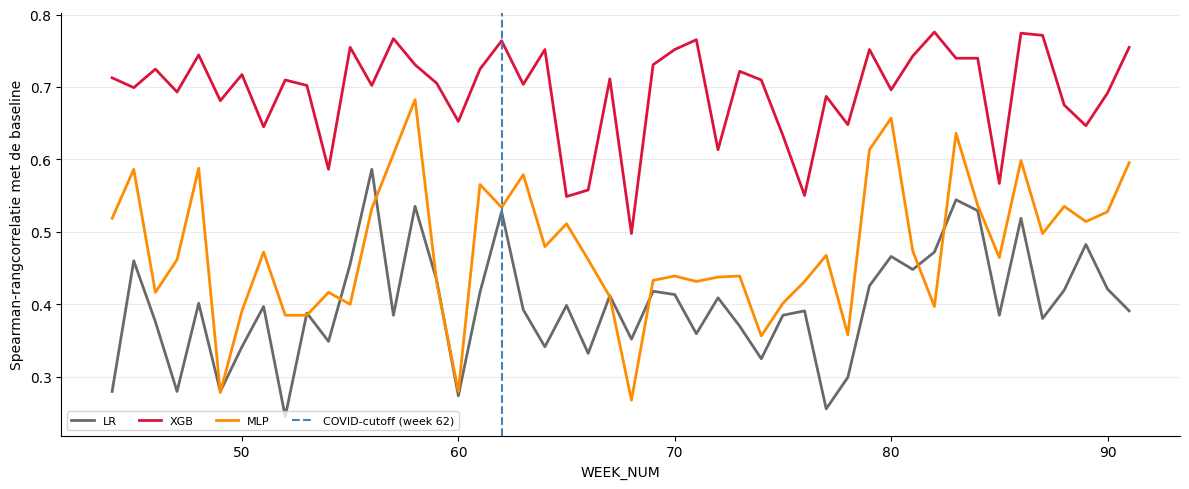

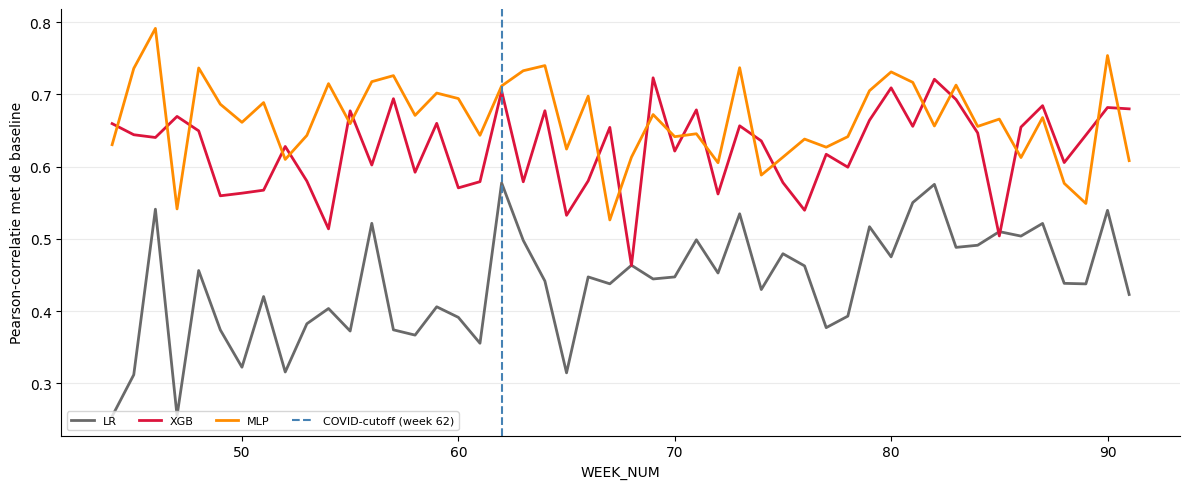

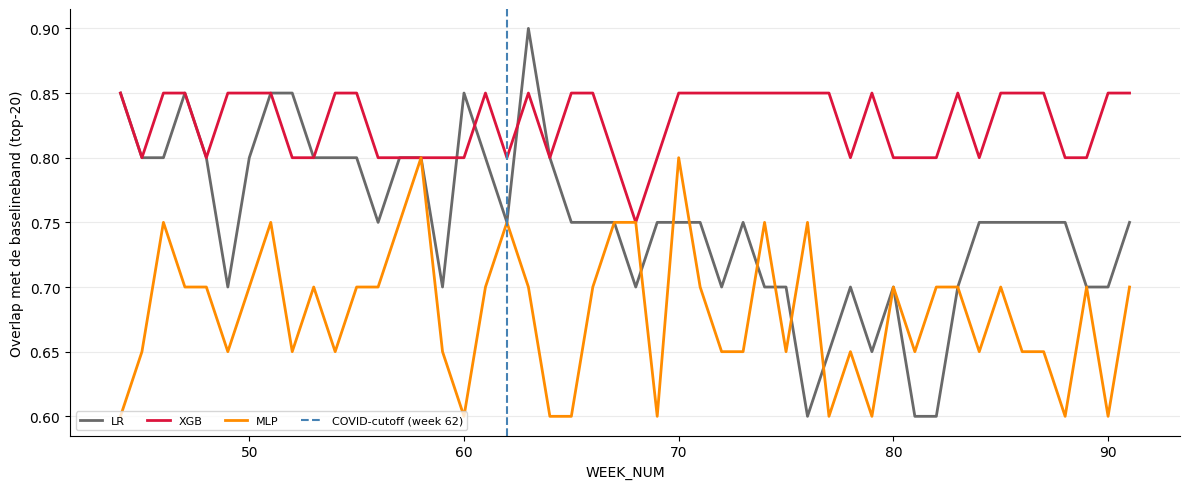

In [51]:
# F4/F5/F6 - Spearman, Pearson en overlap per week, per model. De gestreepte lijn is de
# COVID-cutoff; alles rechts daarvan valt in het post-COVID blok.
def plot_over_time(column, ylabel, filename):
    fig, ax = plt.subplots(figsize=(12, 5))

    for model_name in MODELS:
        model_weekly = weekly[weekly["model"] == model_name]
        ax.plot(model_weekly["week"], model_weekly[column], linewidth=2,
                color=COLORS[model_name], label=model_name)

    ax.axvline(COVID_WEEK, color="steelblue", linestyle="--", linewidth=1.5,
               label=f"COVID-cutoff (week {COVID_WEEK})")

    ax.set_xlabel("WEEK_NUM")
    ax.set_ylabel(ylabel)
    ax.legend(loc="lower left", fontsize=8, ncol=4)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

    fig.tight_layout()
    plt.show()


plot_over_time("spearman", "Spearman-rangcorrelatie met de baseline",
               "spearman_over_time.png")
plot_over_time("pearson", "Pearson-correlatie met de baseline",
               "pearson_over_time.png")
plot_over_time("overlap", f"Overlap met de baselineband (top-{TOP_K})",
               "overlap_over_time.png")

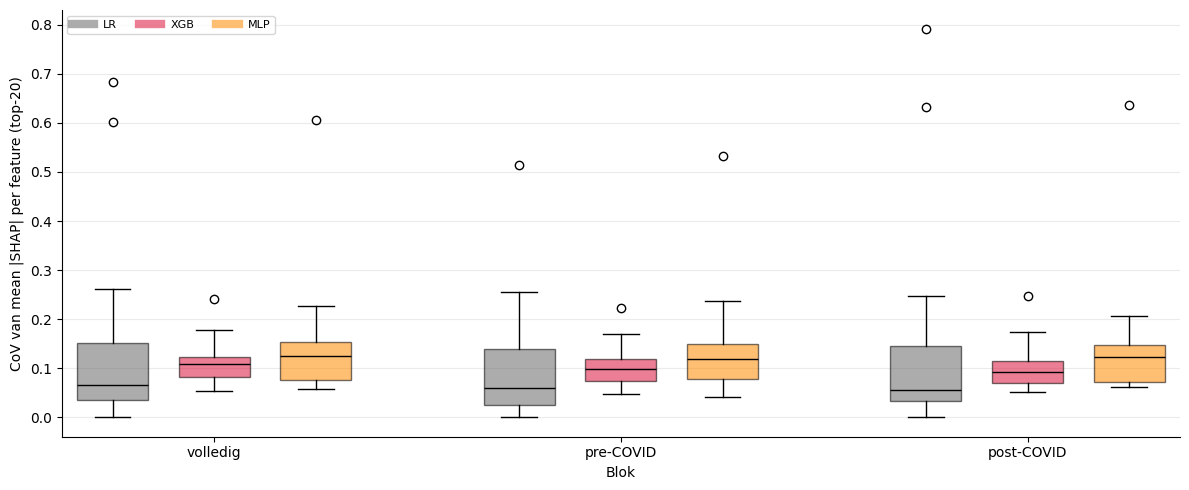

In [52]:
# F7 - Verdeling van de CoV-waarden per feature in de baselineband, per model en per blok.
# De cov_mean uit de samenvattingstabel is het gemiddelde van elke box.
fig, ax = plt.subplots(figsize=(12, 5))

box_data = []
box_positions = []
box_colors = []
tick_positions = []

for block_index, block_name in enumerate(BLOCKS):
    group_start = block_index * (len(MODELS) + 1)
    for model_index, model_name in enumerate(MODELS):
        box_data.append(cov_per_feature[(model_name, block_name)])
        box_positions.append(group_start + model_index)
        box_colors.append(COLORS[model_name])
    tick_positions.append(group_start + (len(MODELS) - 1) / 2)

boxes = ax.boxplot(box_data, positions=box_positions, widths=0.7, patch_artist=True)
for patch, color in zip(boxes["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)
for median in boxes["medians"]:
    median.set_color("black")

ax.set_xticks(tick_positions)
ax.set_xticklabels(list(BLOCKS))
ax.set_xlabel("Blok")
ax.set_ylabel(f"CoV van mean |SHAP| per feature (top-{TOP_K})")

legend_handles = [plt.Line2D([], [], color=COLORS[m], linewidth=6, alpha=0.55, label=m)
                  for m in MODELS]
ax.legend(handles=legend_handles, loc="upper left", fontsize=8, ncol=3)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

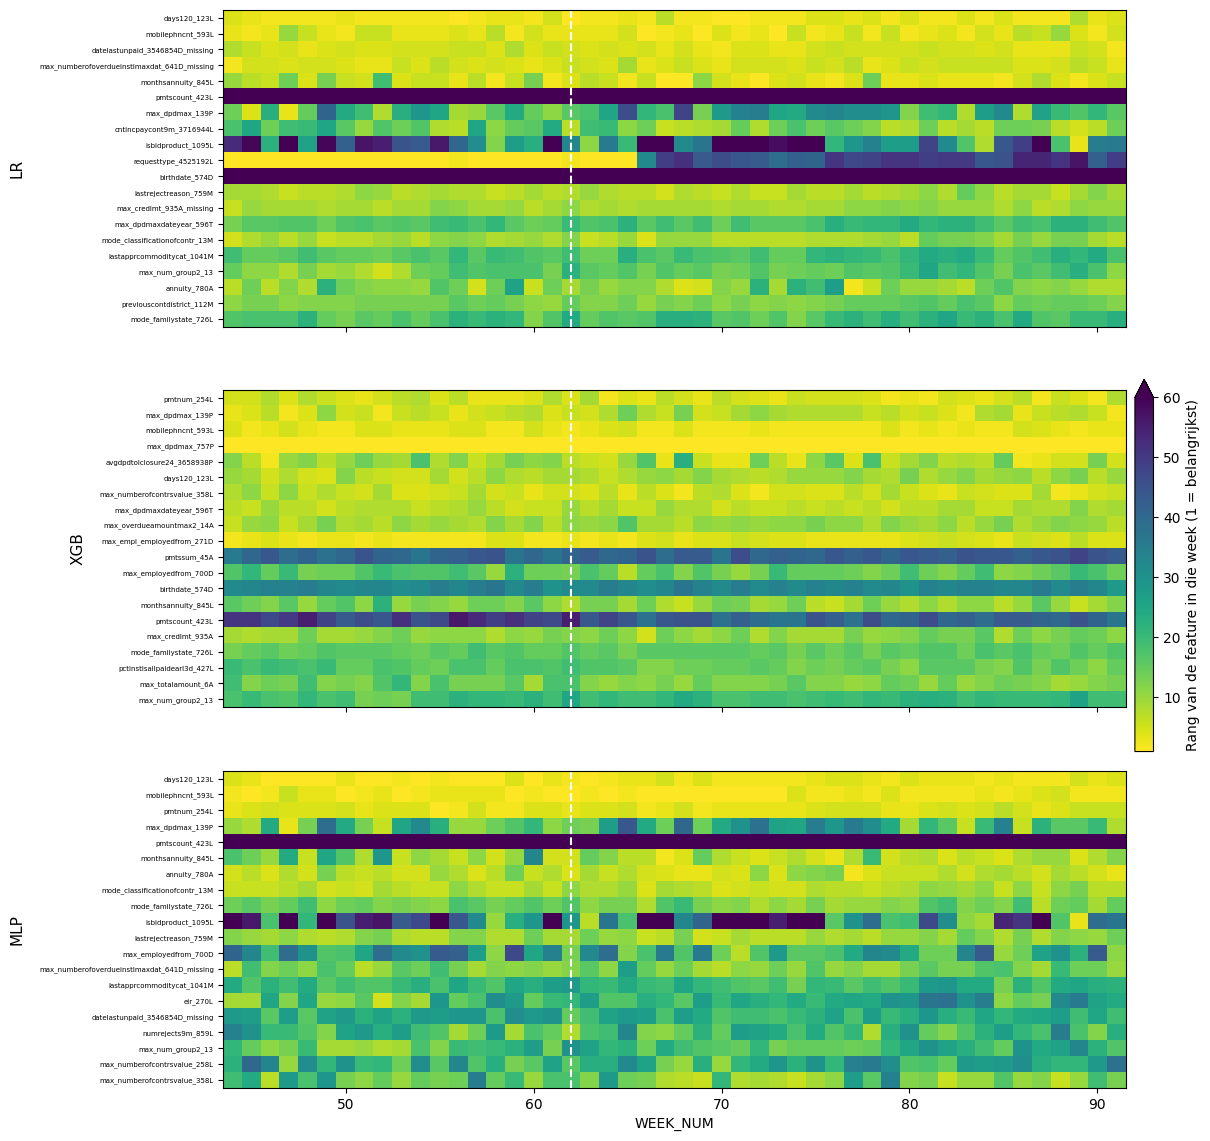

In [53]:
# F8 - Rangdrift van de baselineband: per model de wekelijkse rang van de TOP_K
# baselinefeatures, gemeten over ALLE features, van boven naar beneden in baselinevolgorde.
# Een rij die naar lichter verkleurt is een feature die het model gaandeweg loslaat; de
# rangcorrelatie in F4 vat ditzelfde beeld samen in een getal per week.
RANK_MAX = 60

fig, axes = plt.subplots(len(MODELS), 1, figsize=(12, 14), sharex=True)

for ax, model_name in zip(axes, MODELS):
    week_ranks = tables[model_name].loc[list(TEST_WEEKS)].rank(axis=1, ascending=False)
    band_ranks = week_ranks[bands[model_name]].to_numpy().T

    im = ax.imshow(band_ranks, aspect="auto", cmap="viridis_r", vmin=1, vmax=RANK_MAX,
                   extent=[min(TEST_WEEKS) - 0.5, max(TEST_WEEKS) + 0.5,
                           TOP_K - 0.5, -0.5])
    ax.axvline(COVID_WEEK, color="white", linestyle="--", linewidth=1.5)

    ax.set_yticks(range(TOP_K))
    ax.set_yticklabels(bands[model_name], fontsize=5)
    ax.set_ylabel(model_name, fontsize=11, labelpad=10)

axes[-1].set_xlabel("WEEK_NUM")

cbar = fig.colorbar(im, ax=axes, fraction=0.02, pad=0.01, extend="max")
cbar.set_label("Rang van de feature in die week (1 = belangrijkst)")

plt.show()

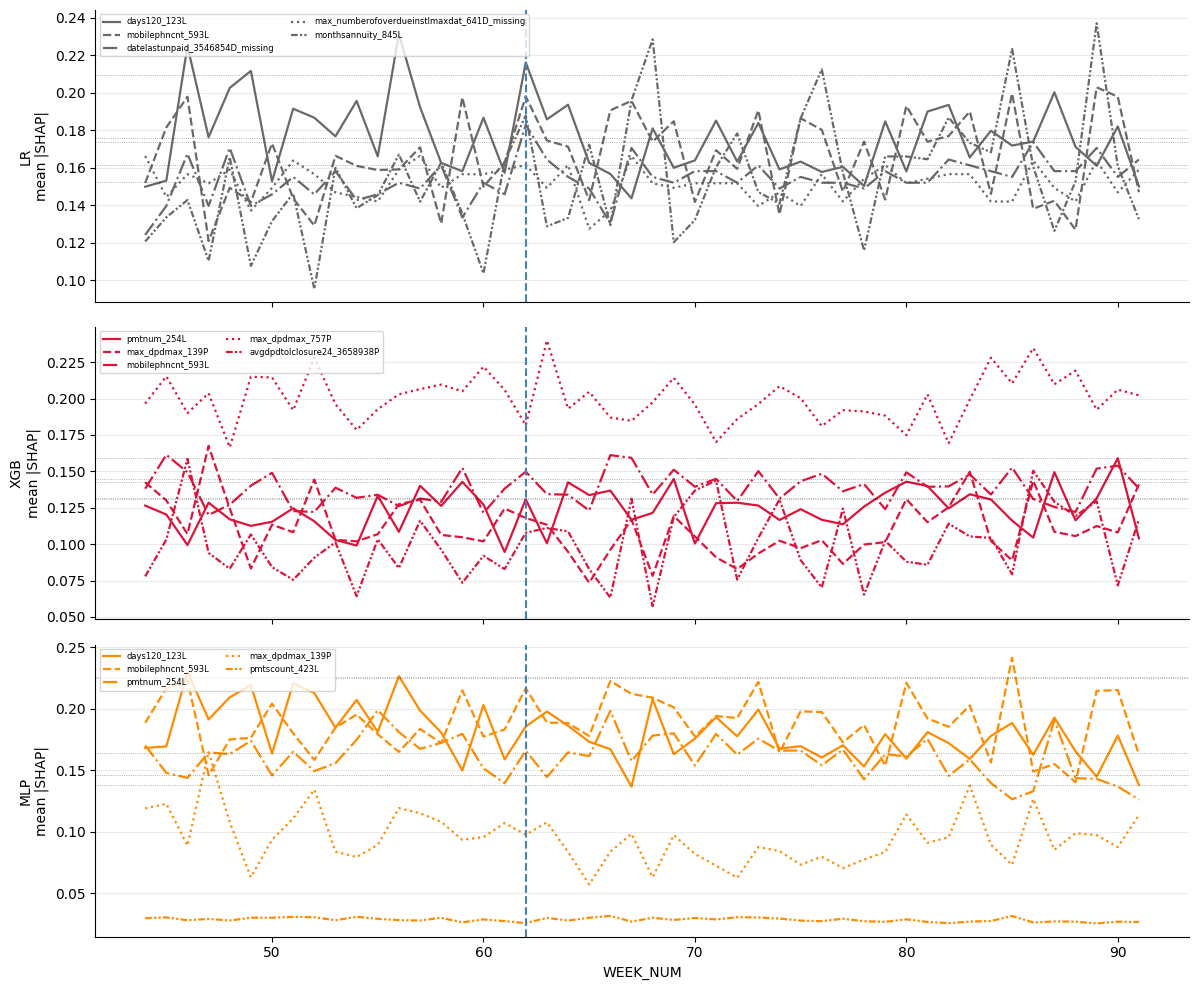

In [54]:
# F9 - Verloop van de mean |SHAP| van de vijf zwaarste baselinefeatures per model, met de
# baselinewaarde als horizontale stippellijn. Dit is het niveau achter F4-F6: het laat zien
# of een dalende correlatie van een echte verschuiving komt, of van features die zo dicht
# bij elkaar liggen dat ze van week tot week van plaats wisselen.
TOP_N_TRAJECTORY = 5
LINESTYLES = ["-", "--", "-.", ":", (0, (3, 1, 1, 1, 1, 1))]

fig, axes = plt.subplots(len(MODELS), 1, figsize=(12, 10), sharex=True)

for ax, model_name in zip(axes, MODELS):
    table = tables[model_name]
    top_features = bands[model_name][:TOP_N_TRAJECTORY]

    for feature, style in zip(top_features, LINESTYLES):
        ax.plot(list(TEST_WEEKS), table.loc[list(TEST_WEEKS), feature], linewidth=1.6,
                color=COLORS[model_name], linestyle=style, label=feature)
        ax.axhline(table.loc[BASELINE_WEEK, feature], color="black",
                   linestyle=":", linewidth=0.6, alpha=0.4)

    ax.axvline(COVID_WEEK, color="steelblue", linestyle="--", linewidth=1.5)
    ax.set_ylabel(f"{model_name}\nmean |SHAP|")
    ax.legend(loc="upper left", fontsize=6, ncol=2)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("WEEK_NUM")

fig.tight_layout()
plt.show()

### Beeswarm per model

De metrieken hierboven vatten elke week samen in één getal per model. De beeswarm laat de
onderliggende verdeling zien: elke stip is één klant, de x-positie is haar SHAP-bijdrage in
log-odds, en de kleur is de waarde van de feature zelf. Daarmee is niet alleen te zien *of*
een feature zwaarder weegt, maar ook *in welke richting* en of dat van een handvol klanten
komt of van de hele verdeling.

Drie momenten per model: de baseline, de middelste week van het pre-COVID blok en de
middelste week van het post-COVID blok.

De cache van 3.3.0 bewaart enkel het gemiddelde per feature, dus de volledige SHAP-matrix
van die drie blokken wordt hier apart berekend en weggeschreven. Dat zijn 9 extra
uitlegbeurten (3 modellen x 3 blokken); bij de volledige instellingen kost dat ongeveer
20 minuten. De baseline wordt daarmee een tweede keer uitgelegd - dat is de prijs voor het
niet moeten hertrekken van de grote cache.

In [55]:
PRE_MID_WEEK = BLOCKS["pre-COVID"][len(BLOCKS["pre-COVID"]) // 2]
POST_MID_WEEK = BLOCKS["post-COVID"][len(BLOCKS["post-COVID"]) // 2]

FOCUS_WEEKS = {
    BASELINE_WEEK: "baseline (trainingsblok)",
    PRE_MID_WEEK: f"week {PRE_MID_WEEK} (midden pre-COVID)",
    POST_MID_WEEK: f"week {POST_MID_WEEK} (midden post-COVID)",
}
BEESWARM_CACHE = f"{RESULTS_DIR}/shap_beeswarm.npz"

focus_samples = {BASELINE_WEEK: X_baseline}
for week in [PRE_MID_WEEK, POST_MID_WEEK]:
    focus_samples[week] = week_samples[week]


def load_beeswarm_cache():
    if not os.path.exists(BEESWARM_CACHE):
        return {}
    with np.load(BEESWARM_CACHE) as stored:
        return {key: stored[key] for key in stored.files}


def save_beeswarm_cache(arrays):
    tmp_path = BEESWARM_CACHE + ".tmp.npz"
    np.savez_compressed(tmp_path, **arrays)
    os.replace(tmp_path, BEESWARM_CACHE)


arrays = load_beeswarm_cache()

for model_name, model in models.items():

    def model_fn(X, model=model):
        return predict_logodds(model, X)

    explainer = shap.PermutationExplainer(model_fn, masker, seed=SEED)

    for week, X_focus in focus_samples.items():
        key = f"values_{model_name}_{week}"
        if key in arrays:
            print(f"{model_name:>3}  week {week:>3}  overgeslagen (al in cache)")
            continue

        start = time.perf_counter()
        explanation = explainer(X_focus, max_evals=MAX_EVALS, batch_size=50_000, silent=True)

        # De featurewaarden zijn identiek voor de drie modellen, dus die staan per week
        # maar een keer in de cache.
        arrays[key] = explanation.values
        arrays[f"data_{week}"] = X_focus.to_numpy(dtype=np.float64)
        save_beeswarm_cache(arrays)

        print(f"{model_name:>3}  week {week:>3}  {time.perf_counter() - start:.1f}s")

print(f"Klaar. Cache: {BEESWARM_CACHE}")

 LR  week  -1  overgeslagen (al in cache)
 LR  week  53  overgeslagen (al in cache)
 LR  week  77  overgeslagen (al in cache)
XGB  week  -1  overgeslagen (al in cache)
XGB  week  53  overgeslagen (al in cache)
XGB  week  77  overgeslagen (al in cache)
MLP  week  -1  overgeslagen (al in cache)
MLP  week  53  overgeslagen (al in cache)
MLP  week  77  overgeslagen (al in cache)
Klaar. Cache: shap_results/shap_beeswarm.npz


#### Eigen top-N per week

F10 legt de drie panelen op de bevroren baselinevolgorde, zodat dezelfde rij telkens dezelfde
feature is en je afleest *hoe de bijdrage van een feature verschuift*.

F11 hieronder doet het omgekeerde: elk paneel krijgt zijn **eigen** top-TOP_K. Daarmee lees je
af *welke features de top in- en uitvallen* - de visuele tegenhanger van de overlap-metriek.
De prijs is dat de rijen niet meer op een lijn liggen tussen de panelen, en dat je dus drie
lijsten featurenamen met elkaar zou moeten vergelijken. Daarom staan de features die niet in
de baselineband zitten in het rood: het aantal rode labels per paneel is precies
`(1 - overlap) * TOP_K` uit de tabel in 3.3.1.

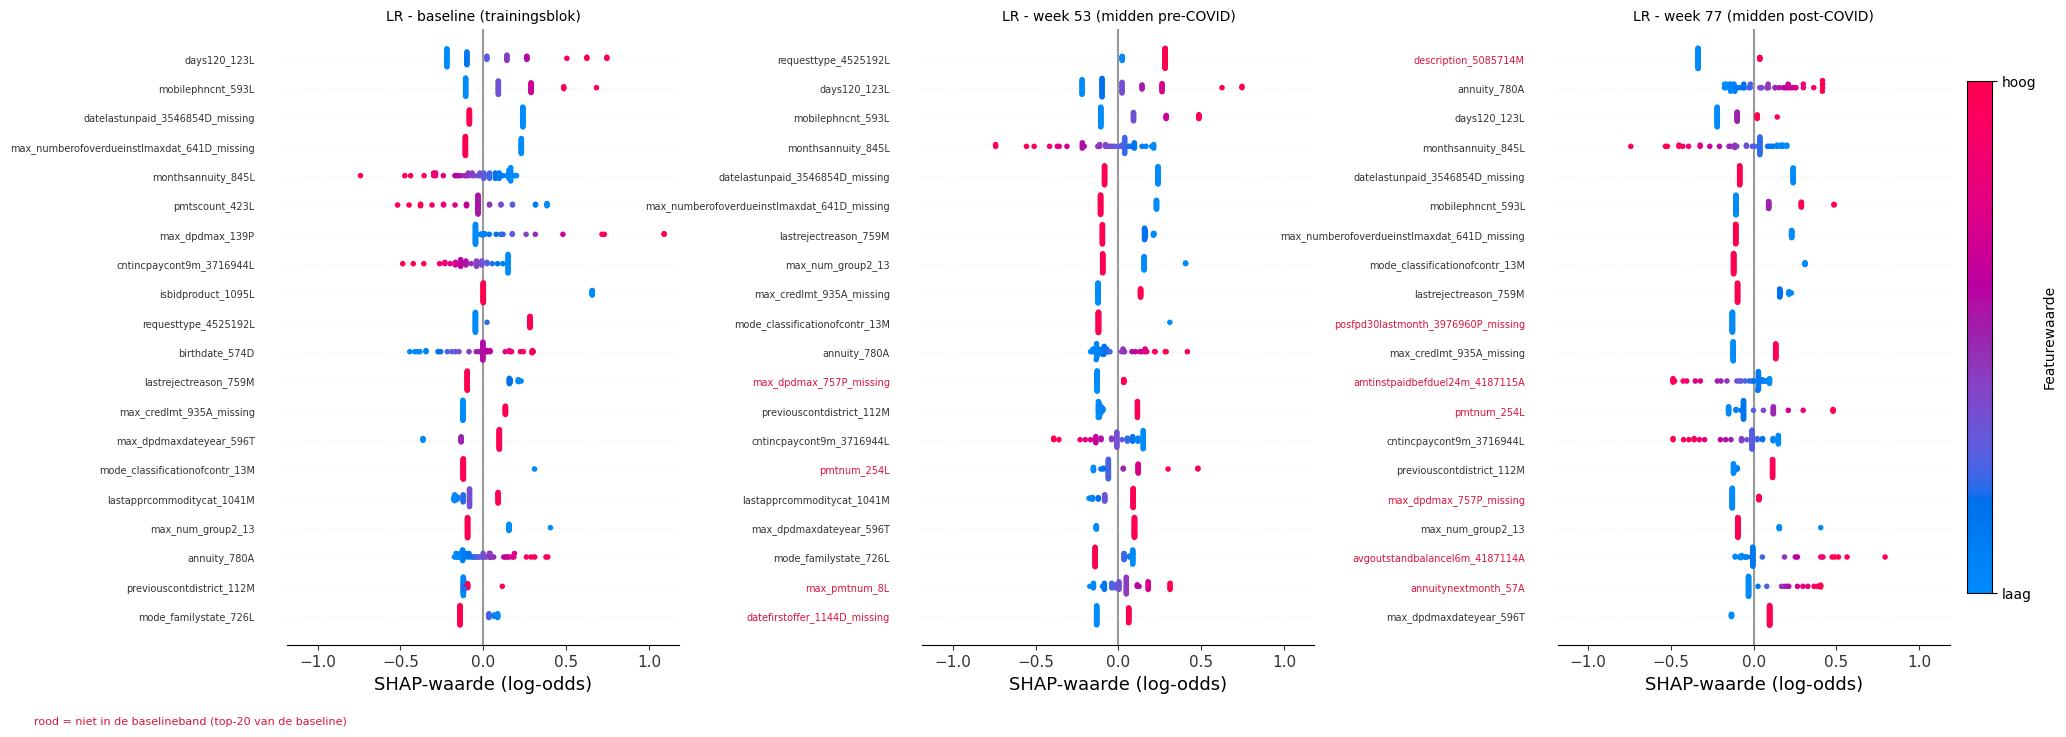

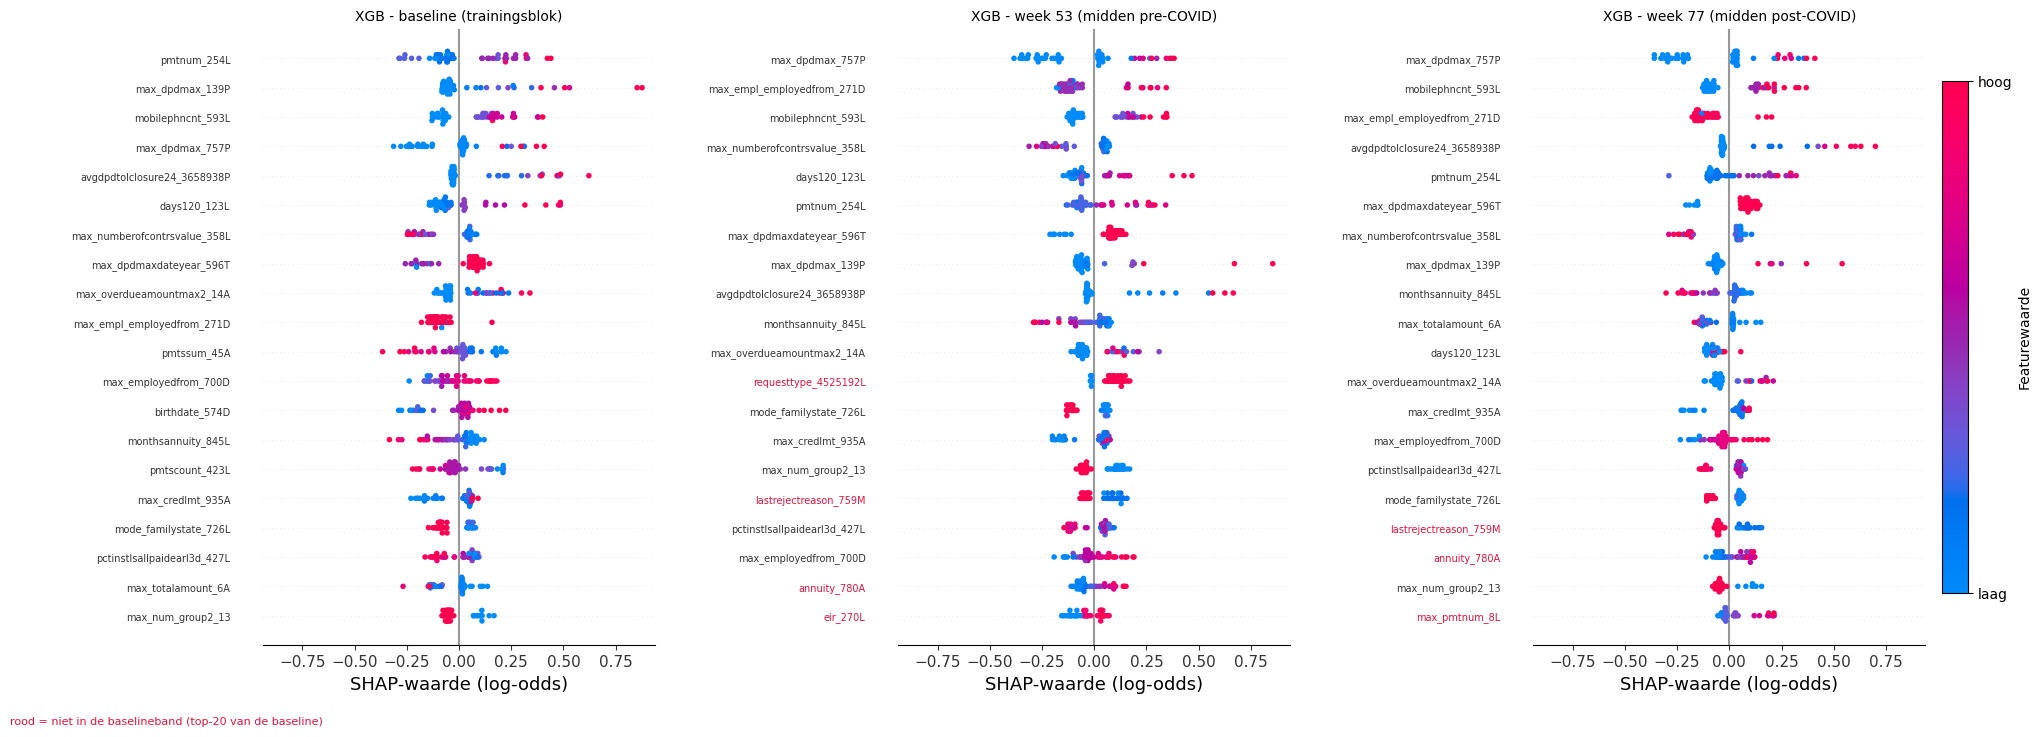

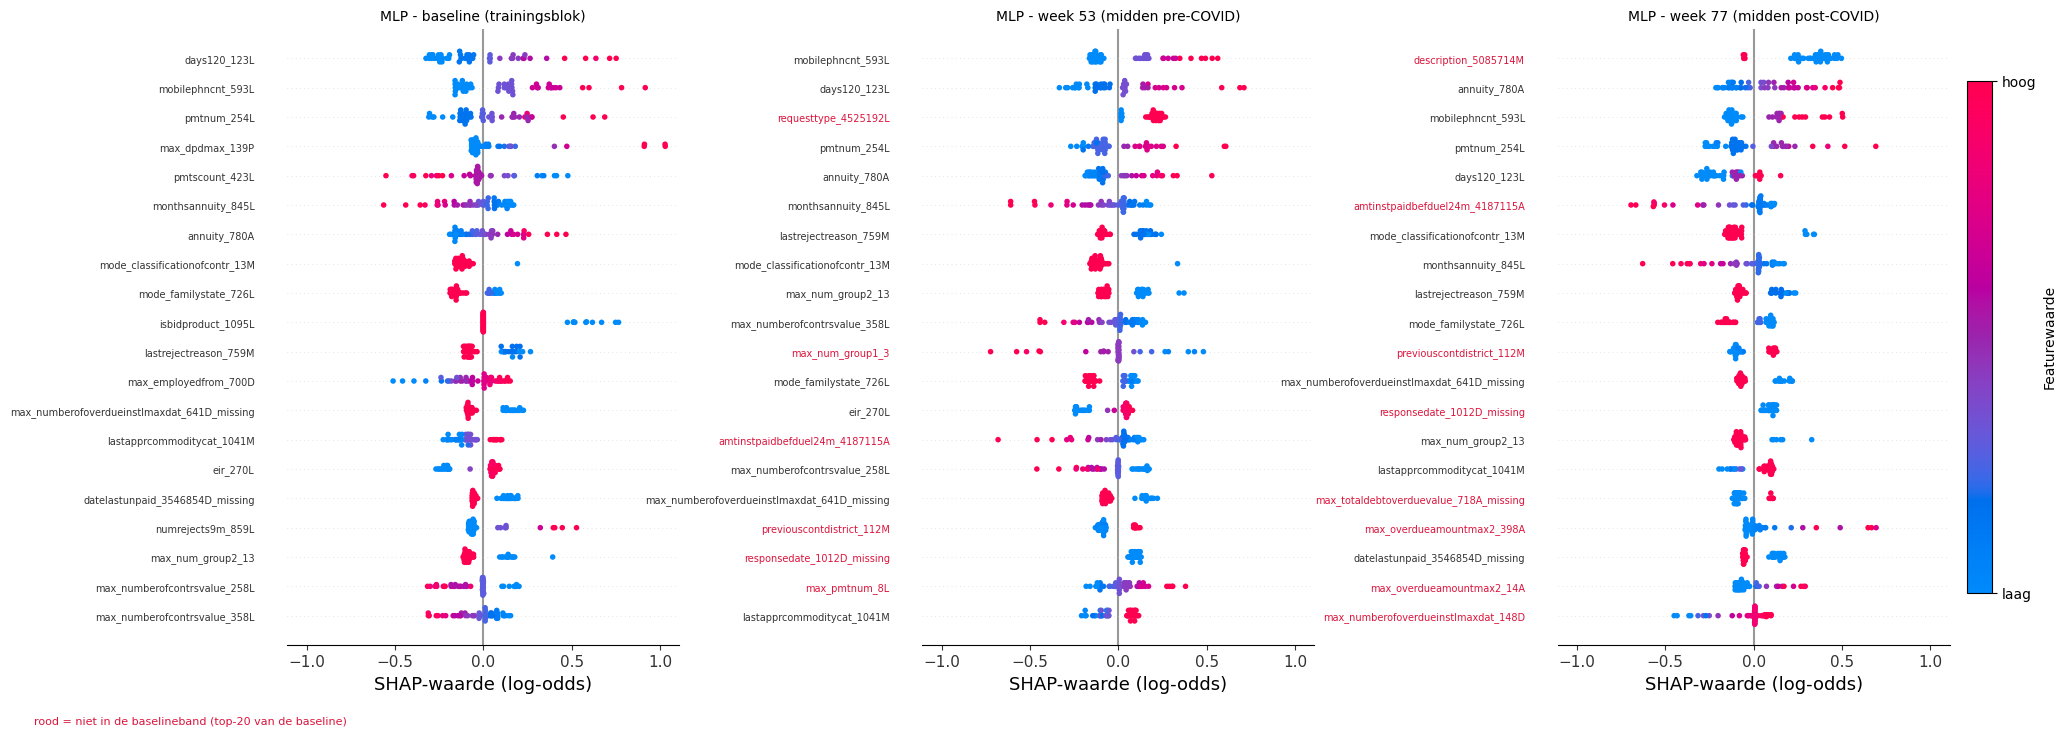

In [56]:
# F11 - Zelfde drie momenten als F10, maar elk paneel krijgt zijn EIGEN top-TOP_K in plaats
# van de bevroren baselinevolgorde. De rijen liggen dus niet op een lijn tussen de panelen;
# de rode labels vangen dat op door de nieuwkomers te markeren.
for model_name in MODELS:
    band_set = set(bands[model_name])

    # wspace ruim: elk paneel draagt nu zijn eigen featurenamen, en die lopen bij de
    # standaardafstand over het paneel ernaast.
    fig, axes = plt.subplots(1, len(FOCUS_WEEKS), figsize=(22, 8),
                             gridspec_kw={"wspace": 0.62})

    for ax, (week, label) in zip(axes, FOCUS_WEEKS.items()):
        values = arrays[f"values_{model_name}_{week}"]
        explanation = shap.Explanation(
            values=values,
            data=arrays[f"data_{week}"],
            feature_names=feature_names,
        )

        week_order = np.argsort(-np.abs(values).mean(axis=0))

        shap.plots.beeswarm(explanation, max_display=TOP_K, order=week_order,
                            color_bar=False, group_remaining_features=False,
                            plot_size=None, ax=ax, show=False)

        # Rood = feature die deze week in de top staat maar niet in de baselineband.
        for tick in ax.get_yticklabels():
            tick.set_fontsize(7)
            if tick.get_text() not in band_set:
                tick.set_color("crimson")

        ax.set_xlabel("SHAP-waarde (log-odds)")
        ax.set_title(f"{model_name} - {label}", fontsize=10)

    limit = max(abs(x) for ax in axes for x in ax.get_xlim())
    for ax in axes:
        ax.set_xlim(-limit, limit)
    for ax in axes[1:]:
        ax.set_xticks(axes[0].get_xticks())
        ax.set_xlim(-limit, limit)

    scale = plt.cm.ScalarMappable(cmap=shap.plots.colors.red_blue)
    scale.set_array([])
    cbar = fig.colorbar(scale, ax=axes, fraction=0.015, pad=0.01, ticks=[0, 1])
    cbar.set_ticklabels(["laag", "hoog"])
    cbar.set_label("Featurewaarde")

    fig.text(0.01, 0.01, f"rood = niet in de baselineband (top-{TOP_K} van de baseline)",
             fontsize=8, color="crimson")

    plt.show()